In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

project_dir = Path("/home/niels/BEP-Niels")

temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
figures_dir = project_dir / "Results-figures"

temp_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Project:", project_dir)
print("Results:", results_dir)

Project: /home/niels/BEP-Niels
Results: /home/niels/BEP-Niels/results


In [4]:
model_start = "1986-01-01T00:00:00Z"
model_end = "1992-01-01T00:00:00Z"

output_start = "1987-01-01"
output_end = "1991-12-31"

forcing_file_base = (
    temp_dir
    / "forcing_basisrun_1987_1995"
    / "work"
    / "diagnostic"
    / "script"
    / "wflow_ERA5_Rhine_1986_1995.nc"
)

forcing_sensitivity_dir = temp_dir / "forcing_sensitivity_short"
forcing_sensitivity_dir.mkdir(exist_ok=True)

print("Base forcing bestaat:", forcing_file_base.exists())
print("Sensitivity forcing map:", forcing_sensitivity_dir)

Base forcing bestaat: True
Sensitivity forcing map: /home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short


In [5]:
short_base_forcing = forcing_sensitivity_dir / "wflow_ERA5_Rhine_1986_1991_base.nc"

if short_base_forcing.exists():
    print("Korte basisforcing bestaat al:")
    print(short_base_forcing)

else:
    ds = xr.open_dataset(forcing_file_base)

    ds_short = ds.sel(
        time=slice("1986-01-01", "1991-12-31")
    )

    ds_short.to_netcdf(short_base_forcing)

    ds.close()
    ds_short.close()

    print("Korte basisforcing aangemaakt:")
    print(short_base_forcing)

Korte basisforcing aangemaakt:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_base.nc


In [6]:
def make_modified_forcing(
    scenario_name,
    pr_factor=1.0,
    pet_factor=1.0,
    tas_delta=0.0
):
    output_file = forcing_sensitivity_dir / f"wflow_ERA5_Rhine_1986_1991_{scenario_name}.nc"

    if output_file.exists():
        print("Bestaande aangepaste forcing gevonden:")
        print(output_file)
        return output_file

    print("Nieuwe aangepaste forcing maken:")
    print(output_file)

    ds = xr.open_dataset(short_base_forcing)

    ds_new = ds.copy()

    ds_new["pr"] = ds_new["pr"] * pr_factor
    ds_new["pet"] = ds_new["pet"] * pet_factor
    ds_new["tas"] = ds_new["tas"] + tas_delta

    ds_new["pr"].attrs = ds["pr"].attrs
    ds_new["pet"].attrs = ds["pet"].attrs
    ds_new["tas"].attrs = ds["tas"].attrs

    ds_new.to_netcdf(output_file)

    ds.close()
    ds_new.close()

    print("Opgeslagen als:")
    print(output_file)

    return output_file

In [8]:
scenarios = {
    "base": {
        "pr_factor": 1.0,
        "pet_factor": 1.0,
        "tas_delta": 0.0
    },
    "pr_minus10": {
        "pr_factor": 0.90,
        "pet_factor": 1.0,
        "tas_delta": 0.0
    },
    "pr_plus10": {
        "pr_factor": 1.10,
        "pet_factor": 1.0,
        "tas_delta": 0.0
    },
    "pet_minus15": {
        "pr_factor": 1.0,
        "pet_factor": 0.85,
        "tas_delta": 0.0
    },
    "pet_plus15": {
        "pr_factor": 1.0,
        "pet_factor": 1.15,
        "tas_delta": 0.0
    },
    "tas_plus1": {
        "pr_factor": 1.0,
        "pet_factor": 1.0,
        "tas_delta": 1.0
    },
    "tas_minus1": {
        "pr_factor": 1.0,
        "pet_factor": 1.0,
        "tas_delta": -1.0
    }
}

print(scenarios.keys())

dict_keys(['base', 'pr_minus10', 'pr_plus10', 'pet_minus15', 'pet_plus15', 'tas_plus1', 'tas_minus1'])


In [10]:
def multiply_tbl_last_column(tbl_file, factor):
    tbl_file = Path(tbl_file)
    text = tbl_file.read_text()
    
    new_lines = []
    
    for line in text.splitlines():
        stripped = line.strip()
        
        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue
        
        parts = line.split()
        
        try:
            old_value = float(parts[-1])
            new_value = old_value * factor
            parts[-1] = str(new_value)
            new_lines.append(" ".join(parts))
        except:
            new_lines.append(line)
    
    tbl_file.write_text("\n".join(new_lines) + "\n")


def apply_parameter_factors(cfg_dir, factors):
    cfg_dir = Path(cfg_dir)
    
    for tbl_name, factor in factors.items():
        files = list(cfg_dir.rglob(tbl_name))
        
        if len(files) == 0:
            print("Niet gevonden:", tbl_name)
            continue
        
        for file in files:
            print("Aanpassen:", file.relative_to(cfg_dir), "factor:", factor)
            multiply_tbl_last_column(file, factor)


def run_wflow_with_forcing(run_name, forcing_file, factors):
    WflowForcing = sources["WflowForcing"]
    
    forcing = WflowForcing(
        start_time=model_start,
        end_time=model_end,
        directory=str(forcing_file.parent),
        shape=str(shape_file),
        netcdfinput=forcing_file.name,
        Precipitation="/pr",
        EvapoTranspiration="/pet",
        Temperature="/tas",
        Inflow=None,
    )
    
    cfg_dir_run = temp_dir / f"run_{run_name}"
    
    if cfg_dir_run.exists():
        print("Oude runmap verwijderen:", cfg_dir_run)
        shutil.rmtree(cfg_dir_run)
    
    model = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )
    
    cfg_file, cfg_dir = model.setup(cfg_dir=str(cfg_dir_run))
    cfg_dir = Path(cfg_dir)
    
    # calibrated_3 parameters toepassen
    apply_parameter_factors(cfg_dir, factors)
    
    model.initialize(cfg_file)
    
    q_values = []
    times = []
    
    i = 0
    
    while model.time < model.end_time:
        model.update()
        
        q_lobith = model.get_value_at_coords(
            "RiverRunoff",
            lat=[float(lat_lobith_model)],
            lon=[float(lon_lobith_model)]
        )[0]
        
        q_values.append(float(q_lobith))
        times.append(model.time_as_datetime)
        
        i += 1
        
        if i % 365 == 0:
            print(
                "Stap:", i,
                "Tijd:", model.time_as_datetime,
                "Q:", round(float(q_lobith), 1)
            )
    
    model.finalize()
    
    output = pd.DataFrame({
        "date": pd.to_datetime(times, utc=True),
        "Q_model_m3s": q_values
    })
    
    output["date"] = output["date"].dt.tz_convert(None).dt.floor("D")
    
    output = output[
        (output["date"] >= output_start) &
        (output["date"] <= output_end)
    ].copy()
    
    output_file = results_dir / f"{run_name}_lobith_daily.csv"
    output.to_csv(output_file, index=False)
    
    print("Run klaar:", run_name)
    print("Opgeslagen als:", output_file)
    
    return output

In [12]:
shape_file = project_dir / "Rhine" / "Rhine.shp"

parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

lat_lobith_model = 51.849999998
lon_lobith_model = 6.0999999998

print("Shape bestaat:", shape_file.exists())
print("Parameter set:", parameter_set.directory)
print("Config bestaat:", parameter_set.config.exists())
print("Lobith modelpunt:", lat_lobith_model, lon_lobith_model)

Shape bestaat: True
Parameter set: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config bestaat: True
Lobith modelpunt: 51.849999998 6.0999999998


In [14]:
factors_calibrated_3 = {
    "EoverR.tbl": 0.75,
    "RootingDepth.tbl": 0.90,
    "N_River.tbl": 4.0
}

print(factors_calibrated_3)

{'EoverR.tbl': 0.75, 'RootingDepth.tbl': 0.9, 'N_River.tbl': 4.0}


In [15]:
nodig = [
    "scenarios",
    "make_modified_forcing",
    "run_wflow_with_forcing",
    "factors_calibrated_3",
    "parameter_set",
    "shape_file",
    "lat_lobith_model",
    "lon_lobith_model"
]

for naam in nodig:
    print(naam, naam in globals())

scenarios True
make_modified_forcing True
run_wflow_with_forcing True
factors_calibrated_3 True
parameter_set True
shape_file True
lat_lobith_model True
lon_lobith_model True


In [16]:
scenario_name = "pet_minus15"

settings = scenarios[scenario_name]

modified_forcing_file = make_modified_forcing(
    scenario_name=scenario_name,
    pr_factor=settings["pr_factor"],
    pet_factor=settings["pet_factor"],
    tas_delta=settings["tas_delta"]
)

run_name = f"calibrated_3_{scenario_name}_1987_1991"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)

    model_scenario = pd.read_csv(run_file)
    model_scenario["date"] = pd.to_datetime(model_scenario["date"])

else:
    model_scenario = run_wflow_with_forcing(
        run_name=run_name,
        forcing_file=modified_forcing_file,
        factors=factors_calibrated_3
    )

model_scenario = model_scenario.rename(
    columns={"Q_model_m3s": f"Q_{scenario_name}_m3s"}
)

model_scenario.head()

Bestaande aangepaste forcing gevonden:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_minus15.nc
Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 8258.5
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3776.1
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 7038.5
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 7535.6
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 5170.5
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 5916.8
Run klaar: calibrated_3_pet_minus15_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_pet_minus15_1987_1991_lobith_daily.csv


,date,Q_pet_minus15_m3s
365,1987-01-01,9428.535156
366,1987-01-02,10691.747070
367,1987-01-03,11940.578125
368,1987-01-04,13043.630859
369,1987-01-05,13823.102539


In [19]:
grdc_file = project_dir / "Data Lobith" / "data grdc" / "6435060_Q_Day.Cmd.txt"

print("GRDC bestand bestaat:", grdc_file.exists())
print(grdc_file)

GRDC bestand bestaat: True
/home/niels/BEP-Niels/Data Lobith/data grdc/6435060_Q_Day.Cmd.txt


In [20]:
df = pd.read_csv(
    grdc_file,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df = df.rename(columns={
    "YYYY-MM-DD": "date",
    "Value": "Q_m3s"
})

df["date"] = pd.to_datetime(df["date"])
df["Q_m3s"] = pd.to_numeric(df["Q_m3s"])

df = df.dropna(subset=["Q_m3s"])

print("Start GRDC:", df["date"].min())
print("Einde GRDC:", df["date"].max())
print("Aantal dagen:", len(df))

df.head()

Start GRDC: 1901-01-01 00:00:00
Einde GRDC: 2020-12-31 00:00:00
Aantal dagen: 43830


,date,hh:mm,Q_m3s
0,1901-01-01,--:--,2035.0
1,1901-01-02,--:--,2270.0
2,1901-01-03,--:--,2445.0
3,1901-01-04,--:--,2325.0
4,1901-01-05,--:--,2175.0


In [21]:
grdc = df[
    (df["date"] >= output_start) &
    (df["date"] <= output_end)
][["date", "Q_m3s"]].copy()

grdc = grdc.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("GRDC selectie start:", grdc["date"].min())
print("GRDC selectie einde:", grdc["date"].max())
print("Aantal dagen:", len(grdc))

grdc.head()

GRDC selectie start: 1987-01-01 00:00:00
GRDC selectie einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s
31411,1987-01-01,4865.0
31412,1987-01-02,5756.0
31413,1987-01-03,6160.0
31414,1987-01-04,6973.0
31415,1987-01-05,7579.0


In [22]:
scenario_name = "pet_minus15"
q_col = f"Q_{scenario_name}_m3s"

comparison_scenario = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

print("Start:", comparison_scenario["date"].min())
print("Einde:", comparison_scenario["date"].max())
print("Aantal dagen:", len(comparison_scenario))

comparison_scenario.head()

Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_pet_minus15_m3s
0,1987-01-01,4865.0,9428.535156
1,1987-01-02,5756.0,10691.747070
2,1987-01-03,6160.0,11940.578125
3,1987-01-04,6973.0,13043.630859
4,1987-01-05,7579.0,13823.102539


In [23]:
scenario_name = "pet_minus15"
q_col = f"Q_{scenario_name}_m3s"

comparison_scenario = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

print("Start:", comparison_scenario["date"].min())
print("Einde:", comparison_scenario["date"].max())
print("Aantal dagen:", len(comparison_scenario))

comparison_scenario.head()

Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_pet_minus15_m3s
0,1987-01-01,4865.0,9428.535156
1,1987-01-02,5756.0,10691.747070
2,1987-01-03,6160.0,11940.578125
3,1987-01-04,6973.0,13043.630859
4,1987-01-05,7579.0,13823.102539


In [24]:
def calculate_scores(data, obs_col, sim_col):
    d = data[[obs_col, sim_col]].dropna().copy()
    
    obs = d[obs_col].astype(float)
    sim = d[sim_col].astype(float)
    
    bias = (sim - obs).mean()
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    
    eps = 1.0
    log_obs = np.log(obs.clip(lower=eps))
    log_sim = np.log(sim.clip(lower=eps))
    
    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()
    
    return pd.Series({
        "bias_m3s": round(bias, 1),
        "rmse_m3s": round(rmse, 1),
        "log_nse": round(log_nse, 3),
        "n_days": len(d)
    })

In [25]:
score_all = calculate_scores(
    comparison_scenario,
    "Q_grdc_m3s",
    q_col
)

score_low = calculate_scores(
    comparison_scenario[comparison_scenario["Q_grdc_m3s"] < 1600],
    "Q_grdc_m3s",
    q_col
)

print("Scores hele periode:")
display(score_all)

print("Scores low-flow dagen, GRDC < 1600:")
display(score_low)

Scores hele periode:


bias_m3s    1007.200
rmse_m3s    1891.600
log_nse       -0.515
n_days      1826.000
dtype: float64

Scores low-flow dagen, GRDC < 1600:


bias_m3s     541.500
rmse_m3s    1056.500
log_nse      -11.779
n_days       669.000
dtype: float64

In [26]:
thresholds = pd.DataFrame([
    {
        "series": "GRDC",
        "days_below_1600": (comparison_scenario["Q_grdc_m3s"] < 1600).sum(),
        "days_below_1020": (comparison_scenario["Q_grdc_m3s"] < 1020).sum()
    },
    {
        "series": scenario_name,
        "days_below_1600": (comparison_scenario[q_col] < 1600).sum(),
        "days_below_1020": (comparison_scenario[q_col] < 1020).sum()
    }
])

thresholds

,series,days_below_1600,days_below_1020
0,GRDC,669,96
1,pet_minus15,495,200


In [27]:
quantiles = pd.DataFrame([
    {
        "series": "GRDC",
        "Q5": comparison_scenario["Q_grdc_m3s"].quantile(0.05),
        "Q10": comparison_scenario["Q_grdc_m3s"].quantile(0.10),
        "Q20": comparison_scenario["Q_grdc_m3s"].quantile(0.20),
        "median": comparison_scenario["Q_grdc_m3s"].quantile(0.50),
        "mean": comparison_scenario["Q_grdc_m3s"].mean()
    },
    {
        "series": scenario_name,
        "Q5": comparison_scenario[q_col].quantile(0.05),
        "Q10": comparison_scenario[q_col].quantile(0.10),
        "Q20": comparison_scenario[q_col].quantile(0.20),
        "median": comparison_scenario[q_col].quantile(0.50),
        "mean": comparison_scenario[q_col].mean()
    }
])

quantiles.round(1)

,series,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,pet_minus15,776.2,980.5,1360.9,2603.6,3230.5


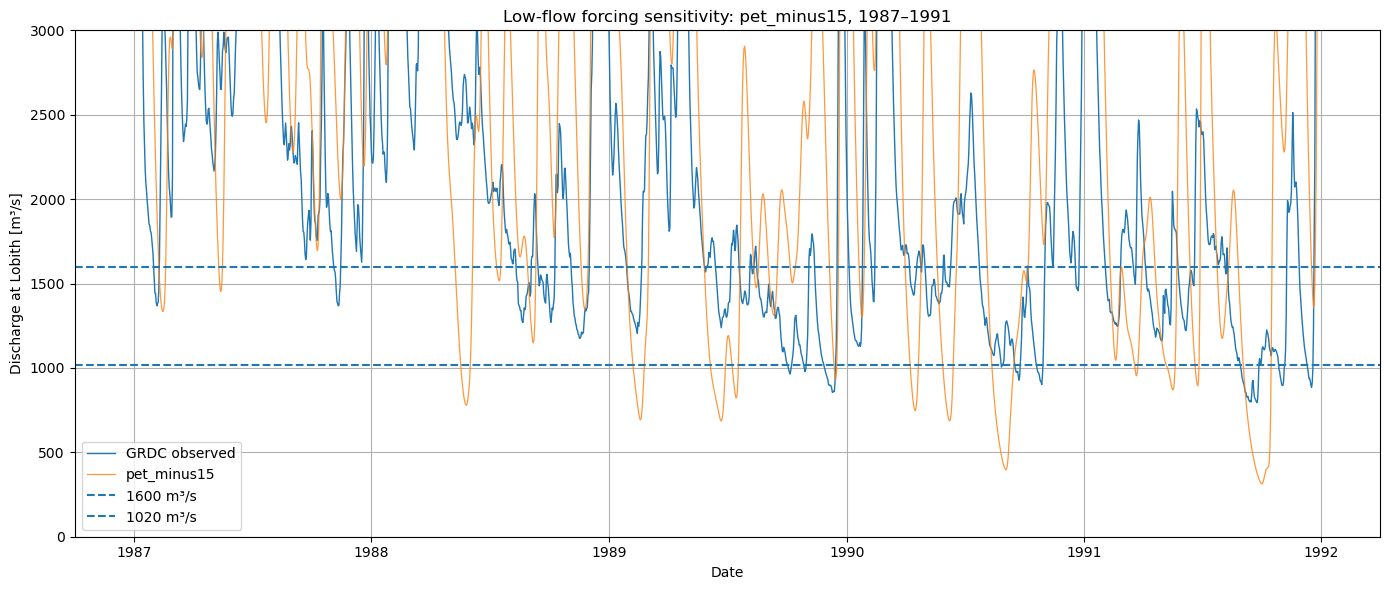

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_scenario["date"],
    comparison_scenario["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_scenario["date"],
    comparison_scenario[q_col],
    label=scenario_name,
    linewidth=0.9,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 3000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title(f"Low-flow forcing sensitivity: {scenario_name}, 1987–1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
scenarios["pet_minus5"] = {
    "pr_factor": 1.0,
    "pet_factor": 0.95,
    "tas_delta": 0.0
}

In [30]:
scenario_name = "pet_minus5"

settings = scenarios[scenario_name]

modified_forcing_file = make_modified_forcing(
    scenario_name=scenario_name,
    pr_factor=settings["pr_factor"],
    pet_factor=settings["pet_factor"],
    tas_delta=settings["tas_delta"]
)

run_name = f"calibrated_3_{scenario_name}_1987_1991"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)

    model_scenario = pd.read_csv(run_file)
    model_scenario["date"] = pd.to_datetime(model_scenario["date"])

else:
    model_scenario = run_wflow_with_forcing(
        run_name=run_name,
        forcing_file=modified_forcing_file,
        factors=factors_calibrated_3
    )

model_scenario = model_scenario.rename(
    columns={"Q_model_m3s": f"Q_{scenario_name}_m3s"}
)

model_scenario.head()

Nieuwe aangepaste forcing maken:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_minus5.nc
Opgeslagen als:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_minus5.nc


Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 8073.6
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3545.8
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6816.3
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 6493.2
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4959.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 4480.1
Run klaar: calibrated_3_pet_minus5_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_pet_minus5_1987_1991_lobith_daily.csv


,date,Q_pet_minus5_m3s
365,1987-01-01,9239.319336
366,1987-01-02,10504.690430
367,1987-01-03,11761.474609
368,1987-01-04,12877.437500
369,1987-01-05,13673.427734


In [31]:
scenario_name = "pet_minus5"
q_col = f"Q_{scenario_name}_m3s"

comparison_pet5 = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

print("Start:", comparison_pet5["date"].min())
print("Einde:", comparison_pet5["date"].max())
print("Aantal dagen:", len(comparison_pet5))

comparison_pet5.head()

Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_pet_minus5_m3s
0,1987-01-01,4865.0,9239.319336
1,1987-01-02,5756.0,10504.690430
2,1987-01-03,6160.0,11761.474609
3,1987-01-04,6973.0,12877.437500
4,1987-01-05,7579.0,13673.427734


In [32]:
score_all_pet5 = calculate_scores(
    comparison_pet5,
    "Q_grdc_m3s",
    q_col
)

score_low_pet5 = calculate_scores(
    comparison_pet5[comparison_pet5["Q_grdc_m3s"] < 1600],
    "Q_grdc_m3s",
    q_col
)

print("Scores hele periode:")
display(score_all_pet5)

print("Scores low-flow dagen, GRDC < 1600:")
display(score_low_pet5)

Scores hele periode:


bias_m3s     738.300
rmse_m3s    1704.100
log_nse       -0.409
n_days      1826.000
dtype: float64

Scores low-flow dagen, GRDC < 1600:


bias_m3s    349.000
rmse_m3s    887.400
log_nse     -10.568
n_days      669.000
dtype: float64

In [33]:
thresholds_pet5 = pd.DataFrame([
    {
        "series": "GRDC",
        "days_below_1600": (comparison_pet5["Q_grdc_m3s"] < 1600).sum(),
        "days_below_1020": (comparison_pet5["Q_grdc_m3s"] < 1020).sum()
    },
    {
        "series": scenario_name,
        "days_below_1600": (comparison_pet5[q_col] < 1600).sum(),
        "days_below_1020": (comparison_pet5[q_col] < 1020).sum()
    }
])

thresholds_pet5

,series,days_below_1600,days_below_1020
0,GRDC,669,96
1,pet_minus5,610,256


In [34]:
quantiles_pet5 = pd.DataFrame([
    {
        "series": "GRDC",
        "Q5": comparison_pet5["Q_grdc_m3s"].quantile(0.05),
        "Q10": comparison_pet5["Q_grdc_m3s"].quantile(0.10),
        "Q20": comparison_pet5["Q_grdc_m3s"].quantile(0.20),
        "median": comparison_pet5["Q_grdc_m3s"].quantile(0.50),
        "mean": comparison_pet5["Q_grdc_m3s"].mean()
    },
    {
        "series": scenario_name,
        "Q5": comparison_pet5[q_col].quantile(0.05),
        "Q10": comparison_pet5[q_col].quantile(0.10),
        "Q20": comparison_pet5[q_col].quantile(0.20),
        "median": comparison_pet5[q_col].quantile(0.50),
        "mean": comparison_pet5[q_col].mean()
    }
])

quantiles_pet5.round(1)

,series,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,pet_minus5,689.1,869.8,1237.7,2302.7,2961.6


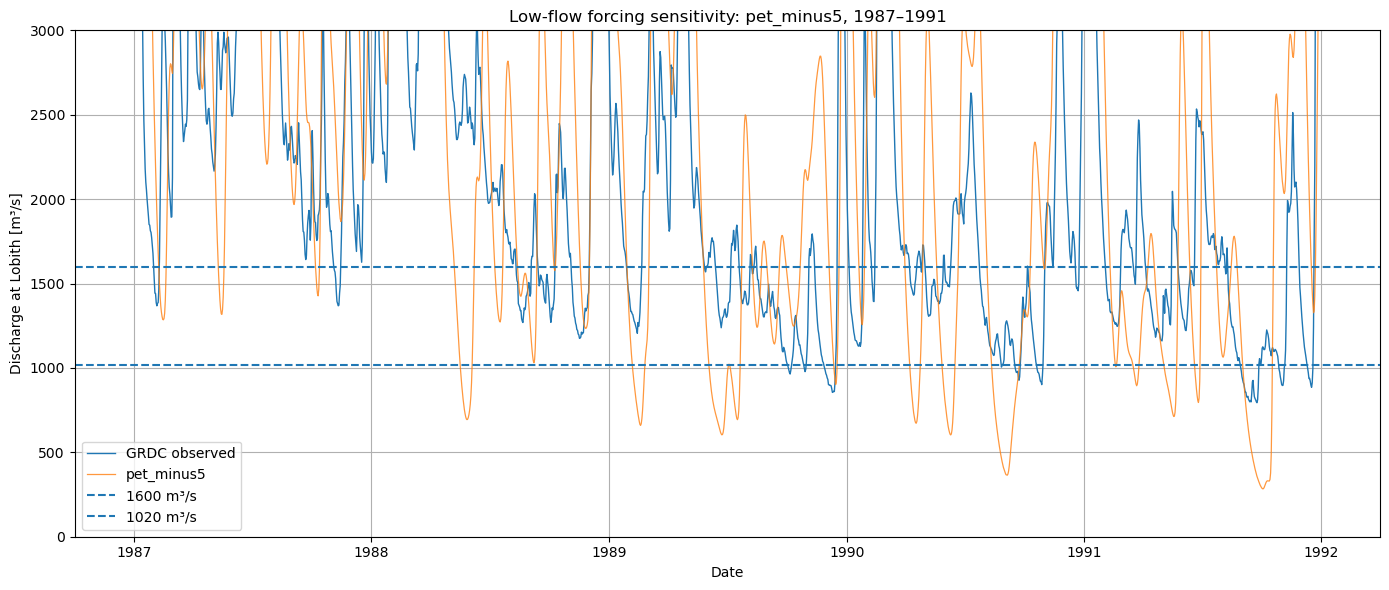

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_pet5["date"],
    comparison_pet5["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_pet5["date"],
    comparison_pet5[q_col],
    label=scenario_name,
    linewidth=0.9,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 3000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title(f"Low-flow forcing sensitivity: {scenario_name}, 1987–1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
scenarios["pet_minus2p5"] = {
    "pr_factor": 1.0,
    "pet_factor": 0.975,
    "tas_delta": 0.0
}

In [37]:
scenario_name = "pet_minus2p5"

settings = scenarios[scenario_name]

modified_forcing_file = make_modified_forcing(
    scenario_name=scenario_name,
    pr_factor=settings["pr_factor"],
    pet_factor=settings["pet_factor"],
    tas_delta=settings["tas_delta"]
)

run_name = f"calibrated_3_{scenario_name}_1987_1991"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)

    model_scenario = pd.read_csv(run_file)
    model_scenario["date"] = pd.to_datetime(model_scenario["date"])

else:
    model_scenario = run_wflow_with_forcing(
        run_name=run_name,
        forcing_file=modified_forcing_file,
        factors=factors_calibrated_3
    )

model_scenario = model_scenario.rename(
    columns={"Q_model_m3s": f"Q_{scenario_name}_m3s"}
)

model_scenario.head()

Nieuwe aangepaste forcing maken:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_minus2p5.nc
Opgeslagen als:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_minus2p5.nc


Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 8021.4
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3466.9
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6733.5
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 6085.2
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4871.6
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 4163.6
Run klaar: calibrated_3_pet_minus2p5_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_pet_minus2p5_1987_1991_lobith_daily.csv


,date,Q_pet_minus2p5_m3s
365,1987-01-01,9186.019531
366,1987-01-02,10452.336914
367,1987-01-03,11711.936523
368,1987-01-04,12832.204102
369,1987-01-05,13633.413086


In [38]:
scenario_name = "pet_minus2p5"
q_col = f"Q_{scenario_name}_m3s"

# Zorg dat de kolom goed heet
if "Q_model_m3s" in model_scenario.columns:
    model_scenario = model_scenario.rename(
        columns={"Q_model_m3s": q_col}
    )

comparison_pet25 = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

print("Start:", comparison_pet25["date"].min())
print("Einde:", comparison_pet25["date"].max())
print("Aantal dagen:", len(comparison_pet25))

comparison_pet25.head()

Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_pet_minus2p5_m3s
0,1987-01-01,4865.0,9186.019531
1,1987-01-02,5756.0,10452.336914
2,1987-01-03,6160.0,11711.936523
3,1987-01-04,6973.0,12832.204102
4,1987-01-05,7579.0,13633.413086


In [39]:
score_all_pet25 = calculate_scores(
    comparison_pet25,
    "Q_grdc_m3s",
    q_col
)

score_low_pet25 = calculate_scores(
    comparison_pet25[comparison_pet25["Q_grdc_m3s"] < 1600],
    "Q_grdc_m3s",
    q_col
)

print("Scores hele periode:")
display(score_all_pet25)

print("Scores low-flow dagen, GRDC < 1600:")
display(score_low_pet25)

Scores hele periode:


bias_m3s     672.900
rmse_m3s    1661.400
log_nse       -0.398
n_days      1826.000
dtype: float64

Scores low-flow dagen, GRDC < 1600:


bias_m3s    304.000
rmse_m3s    850.700
log_nse     -10.406
n_days      669.000
dtype: float64

In [40]:
thresholds_pet25 = pd.DataFrame([
    {
        "series": "GRDC",
        "days_below_1600": (comparison_pet25["Q_grdc_m3s"] < 1600).sum(),
        "days_below_1020": (comparison_pet25["Q_grdc_m3s"] < 1020).sum()
    },
    {
        "series": scenario_name,
        "days_below_1600": (comparison_pet25[q_col] < 1600).sum(),
        "days_below_1020": (comparison_pet25[q_col] < 1020).sum()
    }
])

thresholds_pet25

,series,days_below_1600,days_below_1020
0,GRDC,669,96
1,pet_minus2p5,634,270


In [41]:
quantiles_pet25 = pd.DataFrame([
    {
        "series": "GRDC",
        "Q5": comparison_pet25["Q_grdc_m3s"].quantile(0.05),
        "Q10": comparison_pet25["Q_grdc_m3s"].quantile(0.10),
        "Q20": comparison_pet25["Q_grdc_m3s"].quantile(0.20),
        "median": comparison_pet25["Q_grdc_m3s"].quantile(0.50),
        "mean": comparison_pet25["Q_grdc_m3s"].mean()
    },
    {
        "series": scenario_name,
        "Q5": comparison_pet25[q_col].quantile(0.05),
        "Q10": comparison_pet25[q_col].quantile(0.10),
        "Q20": comparison_pet25[q_col].quantile(0.20),
        "median": comparison_pet25[q_col].quantile(0.50),
        "mean": comparison_pet25[q_col].mean()
    }
])

quantiles_pet25.round(1)

,series,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,pet_minus2p5,669.4,843.9,1200.2,2228.1,2896.3


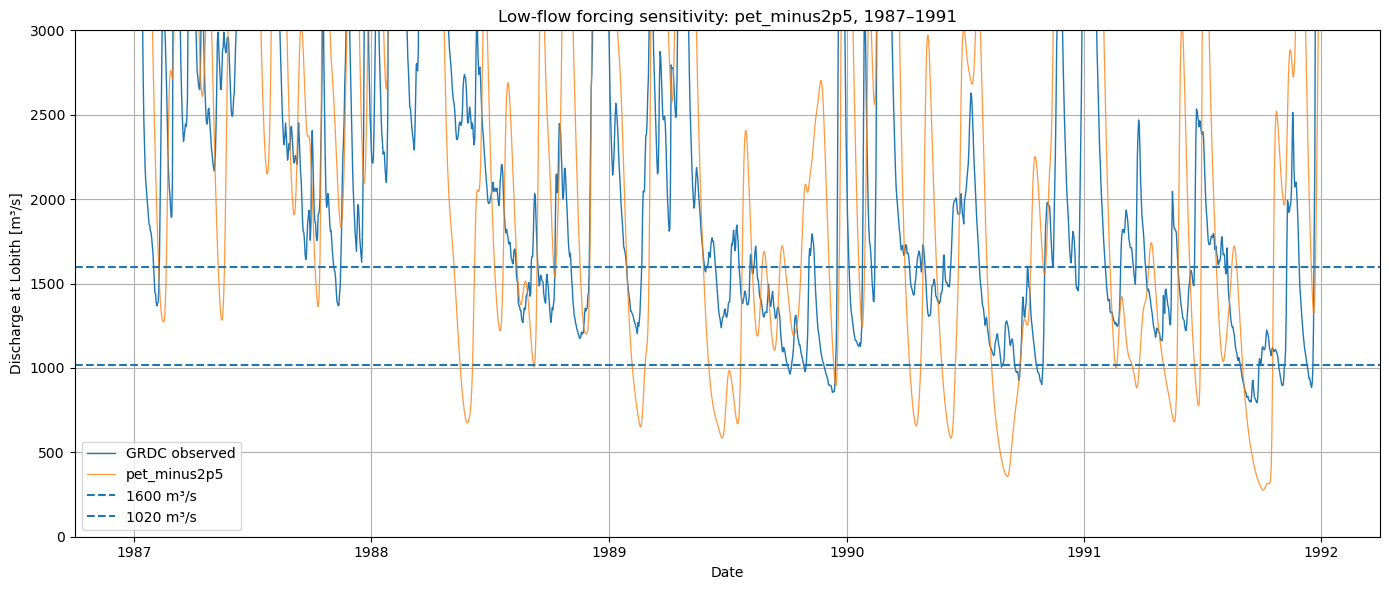

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_pet25["date"],
    comparison_pet25["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_pet25["date"],
    comparison_pet25[q_col],
    label=scenario_name,
    linewidth=0.9,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 3000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title(f"Low-flow forcing sensitivity: {scenario_name}, 1987–1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
scenarios["pr_plus5_pet_plus5"] = {
    "pr_factor": 1.05,
    "pet_factor": 1.05,
    "tas_delta": 0.0
}

In [44]:
scenario_name = "pr_plus5_pet_plus5"

settings = scenarios[scenario_name]

modified_forcing_file = make_modified_forcing(
    scenario_name=scenario_name,
    pr_factor=settings["pr_factor"],
    pet_factor=settings["pet_factor"],
    tas_delta=settings["tas_delta"]
)

run_name = f"calibrated_3_{scenario_name}_1987_1991"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)

    model_scenario = pd.read_csv(run_file)
    model_scenario["date"] = pd.to_datetime(model_scenario["date"])

else:
    model_scenario = run_wflow_with_forcing(
        run_name=run_name,
        forcing_file=modified_forcing_file,
        factors=factors_calibrated_3
    )

model_scenario = model_scenario.rename(
    columns={"Q_model_m3s": f"Q_{scenario_name}_m3s"}
)

model_scenario.head()

Nieuwe aangepaste forcing maken:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pr_plus5_pet_plus5.nc
Opgeslagen als:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pr_plus5_pet_plus5.nc


Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 8631.0
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3557.9
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6900.2
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 6018.6
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 5112.0
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 4439.0
Run klaar: calibrated_3_pr_plus5_pet_plus5_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_pr_plus5_pet_plus5_1987_1991_lobith_daily.csv


,date,Q_pr_plus5_pet_plus5_m3s
365,1987-01-01,9871.352539
366,1987-01-02,11200.466797
367,1987-01-03,12506.764648
368,1987-01-04,13648.157227
369,1987-01-05,14435.337891


In [47]:
scenario_name = "pr_plus5_pet_plus5"
q_col = f"Q_{scenario_name}_m3s"

# Zorg dat de modelkolom goed heet
if "Q_model_m3s" in model_scenario.columns:
    model_scenario = model_scenario.rename(
        columns={"Q_model_m3s": q_col}
    )

comparison_scenario = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

print("Scenario:", scenario_name)
print("Start:", comparison_scenario["date"].min())
print("Einde:", comparison_scenario["date"].max())
print("Aantal dagen:", len(comparison_scenario))

comparison_scenario.head()

Scenario: pr_plus5_pet_plus5
Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_pr_plus5_pet_plus5_m3s
0,1987-01-01,4865.0,9871.352539
1,1987-01-02,5756.0,11200.466797
2,1987-01-03,6160.0,12506.764648
3,1987-01-04,6973.0,13648.157227
4,1987-01-05,7579.0,14435.337891


In [48]:
def calculate_scores(data, obs_col, sim_col):
    d = data[[obs_col, sim_col]].dropna().copy()
    
    obs = d[obs_col].astype(float)
    sim = d[sim_col].astype(float)
    
    bias = (sim - obs).mean()
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    
    eps = 1.0
    log_obs = np.log(obs.clip(lower=eps))
    log_sim = np.log(sim.clip(lower=eps))
    
    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()
    
    return pd.Series({
        "bias_m3s": round(bias, 1),
        "rmse_m3s": round(rmse, 1),
        "log_nse": round(log_nse, 3),
        "n_days": len(d)
    })


score_all = calculate_scores(
    comparison_scenario,
    "Q_grdc_m3s",
    q_col
)

score_low = calculate_scores(
    comparison_scenario[comparison_scenario["Q_grdc_m3s"] < 1600],
    "Q_grdc_m3s",
    q_col
)

print("Scores hele periode:")
display(score_all)

print("Scores low-flow dagen, GRDC < 1600:")
display(score_low)

Scores hele periode:


bias_m3s     755.200
rmse_m3s    1771.800
log_nse       -0.444
n_days      1826.000
dtype: float64

Scores low-flow dagen, GRDC < 1600:


bias_m3s    329.90
rmse_m3s    877.30
log_nse     -10.63
n_days      669.00
dtype: float64

In [49]:
thresholds = pd.DataFrame([
    {
        "series": "GRDC",
        "days_below_1600": (comparison_scenario["Q_grdc_m3s"] < 1600).sum(),
        "days_below_1020": (comparison_scenario["Q_grdc_m3s"] < 1020).sum()
    },
    {
        "series": scenario_name,
        "days_below_1600": (comparison_scenario[q_col] < 1600).sum(),
        "days_below_1020": (comparison_scenario[q_col] < 1020).sum()
    }
])

thresholds

,series,days_below_1600,days_below_1020
0,GRDC,669,96
1,pr_plus5_pet_plus5,622,259


In [50]:
quantiles = pd.DataFrame([
    {
        "series": "GRDC",
        "Q5": comparison_scenario["Q_grdc_m3s"].quantile(0.05),
        "Q10": comparison_scenario["Q_grdc_m3s"].quantile(0.10),
        "Q20": comparison_scenario["Q_grdc_m3s"].quantile(0.20),
        "median": comparison_scenario["Q_grdc_m3s"].quantile(0.50),
        "mean": comparison_scenario["Q_grdc_m3s"].mean()
    },
    {
        "series": scenario_name,
        "Q5": comparison_scenario[q_col].quantile(0.05),
        "Q10": comparison_scenario[q_col].quantile(0.10),
        "Q20": comparison_scenario[q_col].quantile(0.20),
        "median": comparison_scenario[q_col].quantile(0.50),
        "mean": comparison_scenario[q_col].mean()
    }
])

quantiles.round(1)

,series,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,pr_plus5_pet_plus5,675.2,855.5,1208.7,2276.6,2978.5


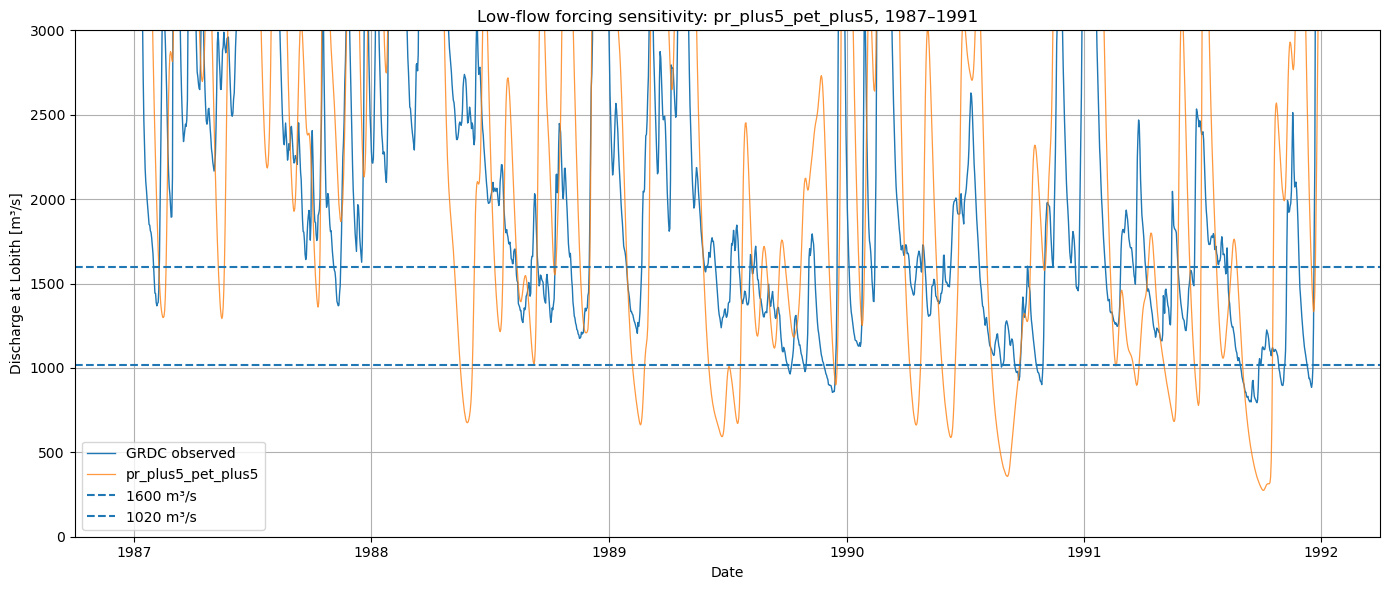

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_scenario["date"],
    comparison_scenario["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_scenario["date"],
    comparison_scenario[q_col],
    label=scenario_name,
    linewidth=0.9,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 3000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title(f"Low-flow forcing sensitivity: {scenario_name}, 1987–1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
scenarios["tas_minus1"] = {
    "pr_factor": 1.0,
    "pet_factor": 1.0,
    "tas_delta": -1.0
}

scenario_name = "tas_minus1"
settings = scenarios[scenario_name]

settings

{'pr_factor': 1.0, 'pet_factor': 1.0, 'tas_delta': -1.0}

In [53]:
modified_forcing_file = make_modified_forcing(
    scenario_name=scenario_name,
    pr_factor=settings["pr_factor"],
    pet_factor=settings["pet_factor"],
    tas_delta=settings["tas_delta"]
)

print(modified_forcing_file)
print("Bestaat:", modified_forcing_file.exists())

Nieuwe aangepaste forcing maken:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_tas_minus1.nc
Opgeslagen als:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_tas_minus1.nc
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_tas_minus1.nc
Bestaat: True


In [54]:
run_name = f"calibrated_3_{scenario_name}_1987_1991"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)

    model_scenario = pd.read_csv(run_file)
    model_scenario["date"] = pd.to_datetime(model_scenario["date"])

else:
    model_scenario = run_wflow_with_forcing(
        run_name=run_name,
        forcing_file=modified_forcing_file,
        factors=factors_calibrated_3
    )

q_col = f"Q_{scenario_name}_m3s"

model_scenario = model_scenario.rename(
    columns={"Q_model_m3s": q_col}
)

model_scenario.head()

Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 7962.2
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3375.2
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6642.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 5663.7
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4775.6
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 3900.9
Run klaar: calibrated_3_tas_minus1_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_tas_minus1_1987_1991_lobith_daily.csv


,date,Q_tas_minus1_m3s
365,1987-01-01,9125.787109
366,1987-01-02,10393.553711
367,1987-01-03,11656.896484
368,1987-01-04,12782.655273
369,1987-01-05,13590.301758


In [55]:
comparison_scenario = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

print("Scenario:", scenario_name)
print("Start:", comparison_scenario["date"].min())
print("Einde:", comparison_scenario["date"].max())
print("Aantal dagen:", len(comparison_scenario))

comparison_scenario.head()

Scenario: tas_minus1
Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_tas_minus1_m3s
0,1987-01-01,4865.0,9125.787109
1,1987-01-02,5756.0,10393.553711
2,1987-01-03,6160.0,11656.896484
3,1987-01-04,6973.0,12782.655273
4,1987-01-05,7579.0,13590.301758


In [56]:
score_all = calculate_scores(
    comparison_scenario,
    "Q_grdc_m3s",
    q_col
)

score_low = calculate_scores(
    comparison_scenario[comparison_scenario["Q_grdc_m3s"] < 1600],
    "Q_grdc_m3s",
    q_col
)

print("Scores hele periode:")
display(score_all)

print("Scores low-flow dagen, GRDC < 1600:")
display(score_low)

Scores hele periode:


bias_m3s     608.300
rmse_m3s    1620.700
log_nse       -0.391
n_days      1826.000
dtype: float64

Scores low-flow dagen, GRDC < 1600:


bias_m3s    260.100
rmse_m3s    815.600
log_nse     -10.283
n_days      669.000
dtype: float64

In [57]:
thresholds = pd.DataFrame([
    {
        "series": "GRDC",
        "days_below_1600": (comparison_scenario["Q_grdc_m3s"] < 1600).sum(),
        "days_below_1020": (comparison_scenario["Q_grdc_m3s"] < 1020).sum()
    },
    {
        "series": scenario_name,
        "days_below_1600": (comparison_scenario[q_col] < 1600).sum(),
        "days_below_1020": (comparison_scenario[q_col] < 1020).sum()
    }
])

thresholds

,series,days_below_1600,days_below_1020
0,GRDC,669,96
1,tas_minus1,660,286


In [58]:
quantiles = pd.DataFrame([
    {
        "series": "GRDC",
        "Q5": comparison_scenario["Q_grdc_m3s"].quantile(0.05),
        "Q10": comparison_scenario["Q_grdc_m3s"].quantile(0.10),
        "Q20": comparison_scenario["Q_grdc_m3s"].quantile(0.20),
        "median": comparison_scenario["Q_grdc_m3s"].quantile(0.50),
        "mean": comparison_scenario["Q_grdc_m3s"].mean()
    },
    {
        "series": scenario_name,
        "Q5": comparison_scenario[q_col].quantile(0.05),
        "Q10": comparison_scenario[q_col].quantile(0.10),
        "Q20": comparison_scenario[q_col].quantile(0.20),
        "median": comparison_scenario[q_col].quantile(0.50),
        "mean": comparison_scenario[q_col].mean()
    }
])

quantiles.round(1)

,series,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,tas_minus1,649.4,811.6,1162.0,2167.7,2831.7


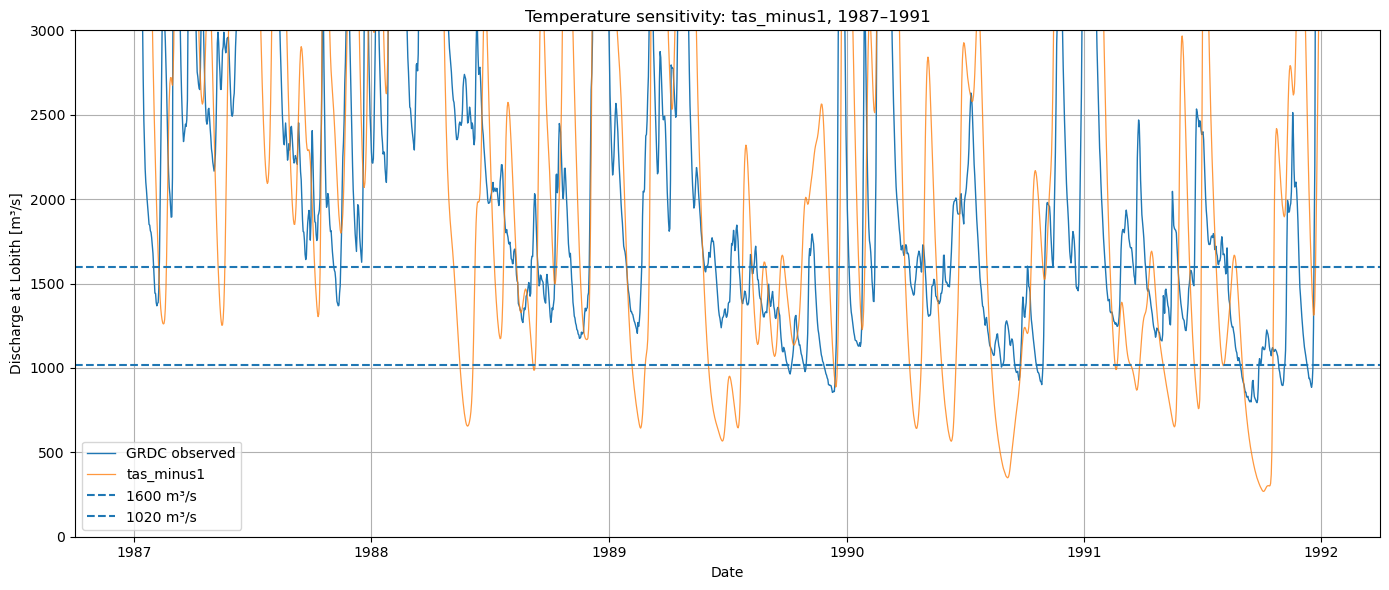

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_scenario["date"],
    comparison_scenario["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_scenario["date"],
    comparison_scenario[q_col],
    label=scenario_name,
    linewidth=0.9,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 3000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title(f"Temperature sensitivity: {scenario_name}, 1987–1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
base_run_name = "calibrated_3_base_1987_1991"
base_run_file = results_dir / f"{base_run_name}_lobith_daily.csv"

if base_run_file.exists():
    print("Bestaande calibrated_3 basisrun gevonden:")
    print(base_run_file)
    
    model_base = pd.read_csv(base_run_file)
    model_base["date"] = pd.to_datetime(model_base["date"])

else:
    print("Geen bestaande calibrated_3 basisrun gevonden. Run wordt nu gedraaid.")
    
    model_base = run_wflow_with_forcing(
        run_name=base_run_name,
        forcing_file=short_base_forcing,
        factors=factors_calibrated_3
    )

model_base = model_base.rename(
    columns={"Q_model_m3s": "Q_calibrated_3_m3s"}
)

model_base.head()

Geen bestaande calibrated_3 basisrun gevonden. Run wordt nu gedraaid.
Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 7962.2
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3375.2
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6642.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 5663.7
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4775.6
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 3900.9
Run klaar: calibrated_3_base_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_base_1987_1991_lobith_daily.csv


,date,Q_calibrated_3_m3s
365,1987-01-01,9125.787109
366,1987-01-02,10393.553711
367,1987-01-03,11656.896484
368,1987-01-04,12782.655273
369,1987-01-05,13590.301758


In [63]:
comparison_calibrated_3 = pd.merge(
    grdc,
    model_base[["date", "Q_calibrated_3_m3s"]],
    on="date",
    how="inner"
)

print("Start:", comparison_calibrated_3["date"].min())
print("Einde:", comparison_calibrated_3["date"].max())
print("Aantal dagen:", len(comparison_calibrated_3))

comparison_calibrated_3.head()

Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00
Aantal dagen: 1826


,date,Q_grdc_m3s,Q_calibrated_3_m3s
0,1987-01-01,4865.0,9125.787109
1,1987-01-02,5756.0,10393.553711
2,1987-01-03,6160.0,11656.896484
3,1987-01-04,6973.0,12782.655273
4,1987-01-05,7579.0,13590.301758


In [64]:
# Alleen uitvoeren als je ook Q_calibrated_3_m3s beschikbaar hebt

diff = comparison_scenario[q_col] - comparison_calibrated_3["Q_calibrated_3_m3s"]

print("Max absoluut verschil:", diff.abs().max())
print("Gemiddeld verschil:", diff.mean())
print("Aantal dagen met verschil:", (diff.abs() > 0.0001).sum())

Max absoluut verschil: 0.0
Gemiddeld verschil: 0.0
Aantal dagen met verschil: 0


In [67]:
def make_seasonal_pet_forcing(
    scenario_name,
    pet_factor=0.95,
    months=[4, 5, 6, 7, 8, 9]
):
    output_file = forcing_sensitivity_dir / f"wflow_ERA5_Rhine_1986_1991_{scenario_name}.nc"

    if output_file.exists():
        print("Bestaande aangepaste forcing gevonden:")
        print(output_file)
        return output_file

    print("Nieuwe seizoensforcing maken:")
    print(output_file)

    ds = xr.open_dataset(short_base_forcing)
    ds_new = ds.copy()

    month_mask = ds_new["time"].dt.month.isin(months)

    ds_new["pet"] = ds_new["pet"].where(
        ~month_mask,
        ds_new["pet"] * pet_factor
    )

    ds_new["pet"].attrs = ds["pet"].attrs

    ds_new.to_netcdf(output_file)

    ds.close()
    ds_new.close()

    print("Opgeslagen als:")
    print(output_file)

    return output_file

In [68]:
scenario_name = "pet_summer_minus5"

modified_forcing_file = make_seasonal_pet_forcing(
    scenario_name=scenario_name,
    pet_factor=0.95,
    months=[4, 5, 6, 7, 8, 9]
)

run_name = f"calibrated_3_{scenario_name}_1987_1991"
run_file = results_dir / f"{run_name}_lobith_daily.csv"

if run_file.exists():
    print("Bestaande output gevonden:")
    print(run_file)

    model_scenario = pd.read_csv(run_file)
    model_scenario["date"] = pd.to_datetime(model_scenario["date"])

else:
    model_scenario = run_wflow_with_forcing(
        run_name=run_name,
        forcing_file=modified_forcing_file,
        factors=factors_calibrated_3
    )

q_col = f"Q_{scenario_name}_m3s"

model_scenario = model_scenario.rename(
    columns={"Q_model_m3s": q_col}
)

model_scenario.head()

Nieuwe seizoensforcing maken:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_summer_minus5.nc
Opgeslagen als:
/home/niels/BEP-Niels/temp_runs/forcing_sensitivity_short/wflow_ERA5_Rhine_1986_1991_pet_summer_minus5.nc


Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 7981.4
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3421.7
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 6766.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 6345.2
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4882.0
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 4279.3
Run klaar: calibrated_3_pet_summer_minus5_1987_1991
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_3_pet_summer_minus5_1987_1991_lobith_daily.csv


,date,Q_pet_summer_minus5_m3s
365,1987-01-01,9144.715820
366,1987-01-02,10410.934570
367,1987-01-03,11671.589844
368,1987-01-04,12794.039062
369,1987-01-05,13598.396484


In [69]:
comparison_scenario = pd.merge(
    grdc,
    model_scenario[["date", q_col]],
    on="date",
    how="inner"
)

score_all = calculate_scores(
    comparison_scenario,
    "Q_grdc_m3s",
    q_col
)

score_low = calculate_scores(
    comparison_scenario[comparison_scenario["Q_grdc_m3s"] < 1600],
    "Q_grdc_m3s",
    q_col
)

print("Scores hele periode:")
display(score_all)

print("Scores low-flow dagen, GRDC < 1600:")
display(score_low)

thresholds = pd.DataFrame([
    {
        "series": "GRDC",
        "days_below_1600": (comparison_scenario["Q_grdc_m3s"] < 1600).sum(),
        "days_below_1020": (comparison_scenario["Q_grdc_m3s"] < 1020).sum()
    },
    {
        "series": scenario_name,
        "days_below_1600": (comparison_scenario[q_col] < 1600).sum(),
        "days_below_1020": (comparison_scenario[q_col] < 1020).sum()
    }
])

display(thresholds)

quantiles = pd.DataFrame([
    {
        "series": "GRDC",
        "Q5": comparison_scenario["Q_grdc_m3s"].quantile(0.05),
        "Q10": comparison_scenario["Q_grdc_m3s"].quantile(0.10),
        "Q20": comparison_scenario["Q_grdc_m3s"].quantile(0.20),
        "median": comparison_scenario["Q_grdc_m3s"].quantile(0.50),
        "mean": comparison_scenario["Q_grdc_m3s"].mean()
    },
    {
        "series": scenario_name,
        "Q5": comparison_scenario[q_col].quantile(0.05),
        "Q10": comparison_scenario[q_col].quantile(0.10),
        "Q20": comparison_scenario[q_col].quantile(0.20),
        "median": comparison_scenario[q_col].quantile(0.50),
        "mean": comparison_scenario[q_col].mean()
    }
])

display(quantiles.round(1))

Scores hele periode:


bias_m3s     703.600
rmse_m3s    1676.600
log_nse       -0.397
n_days      1826.000
dtype: float64

Scores low-flow dagen, GRDC < 1600:


bias_m3s    332.900
rmse_m3s    872.000
log_nse     -10.438
n_days      669.000
dtype: float64

,series,days_below_1600,days_below_1020
0,GRDC,669,96
1,pet_summer_minus5,620,267


,series,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,pet_summer_minus5,679.7,860.4,1215.7,2286.3,2927.0


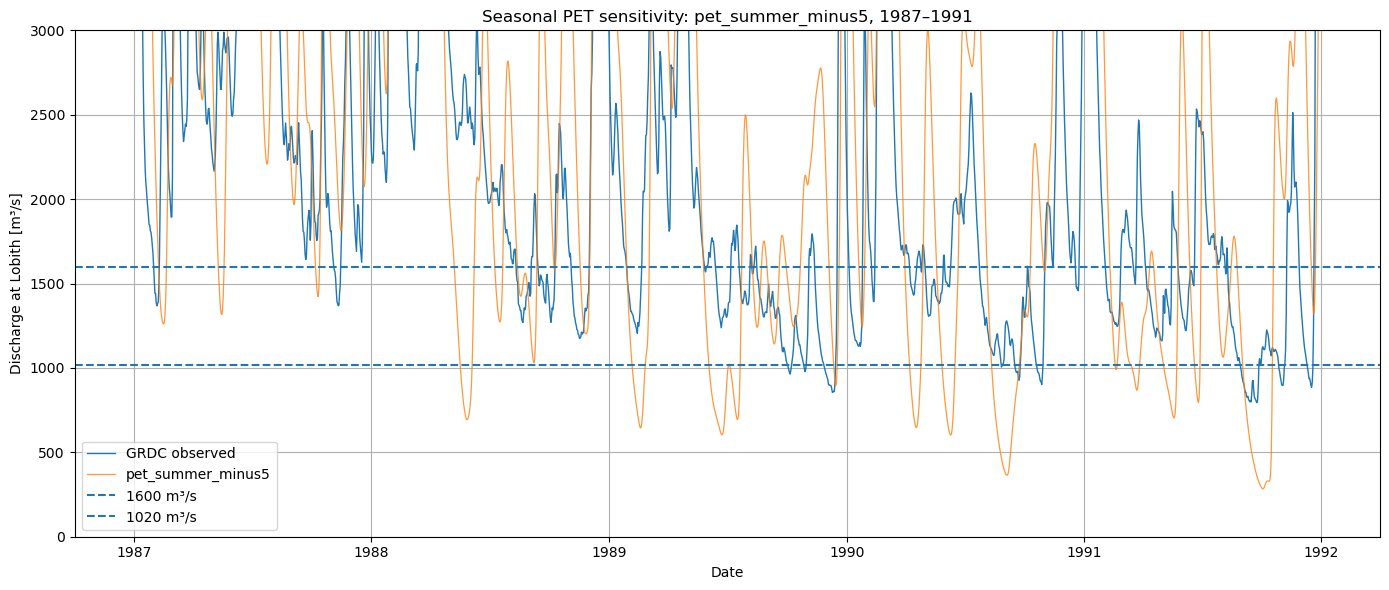

In [70]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_scenario["date"],
    comparison_scenario["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_scenario["date"],
    comparison_scenario[q_col],
    label=scenario_name,
    linewidth=0.9,
    alpha=0.8
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 3000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title(f"Seasonal PET sensitivity: {scenario_name}, 1987–1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()